In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

2025-10-16 18:27:37.244082: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-16 18:27:39.399850: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-16 18:27:43.738791: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
url= '../data/Concrete_Data.xls'
df_raw = pd.read_excel(url)
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [3]:
df_baking = df_raw.copy()
columns = [
    'cement', 'blast_furnance_slag', 'fly_ash', 'water',
    'supperplasticizer','coarse_aggregate','fine_aggregate',
    'age','concrete_compressive_strength'
    ]
df_baking.columns = columns
df = df_baking.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnance_slag            1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   supperplasticizer              1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [4]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=2025)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.shape, df_test.shape

((824, 9), (206, 9))

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,824.0,278.074320,105.202346,102.000000,190.255000,255.000000,350.000000,540.000000
blast_furnance_slag,824.0,76.231311,86.630413,0.000000,0.000000,26.000000,145.000000,359.400000
fly_ash,824.0,53.503083,64.244911,0.000000,0.000000,0.000000,118.270000,200.100000
water,824.0,181.901396,21.936752,121.750000,164.900000,185.700000,193.000000,247.000000
supperplasticizer,824.0,6.186624,6.094910,0.000000,0.000000,6.325000,10.300000,32.200000
coarse_aggregate,824.0,971.264211,77.333406,801.000000,932.000000,968.000000,1028.400000,1134.300000
fine_aggregate,824.0,773.822100,80.960805,594.000000,729.750000,779.510000,825.125000,992.600000
age,824.0,46.007282,63.292854,1.000000,12.250000,28.000000,56.000000,365.000000
concrete_compressive_strength,824.0,35.512051,16.683885,2.331808,23.728144,33.729166,45.367521,82.599225


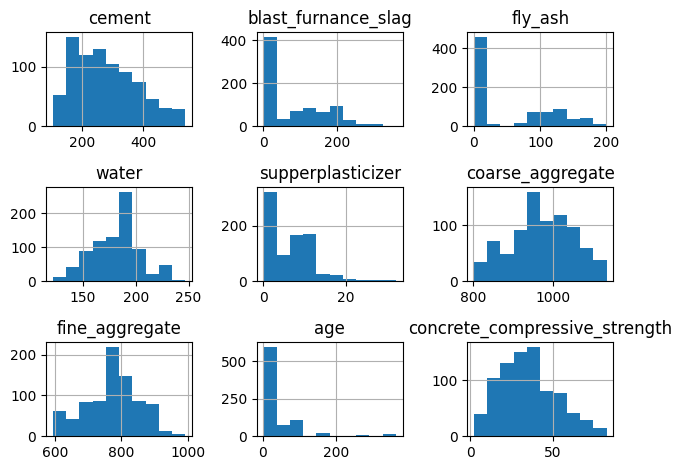

In [6]:
df_train.hist()
plt.tight_layout()
plt.show()

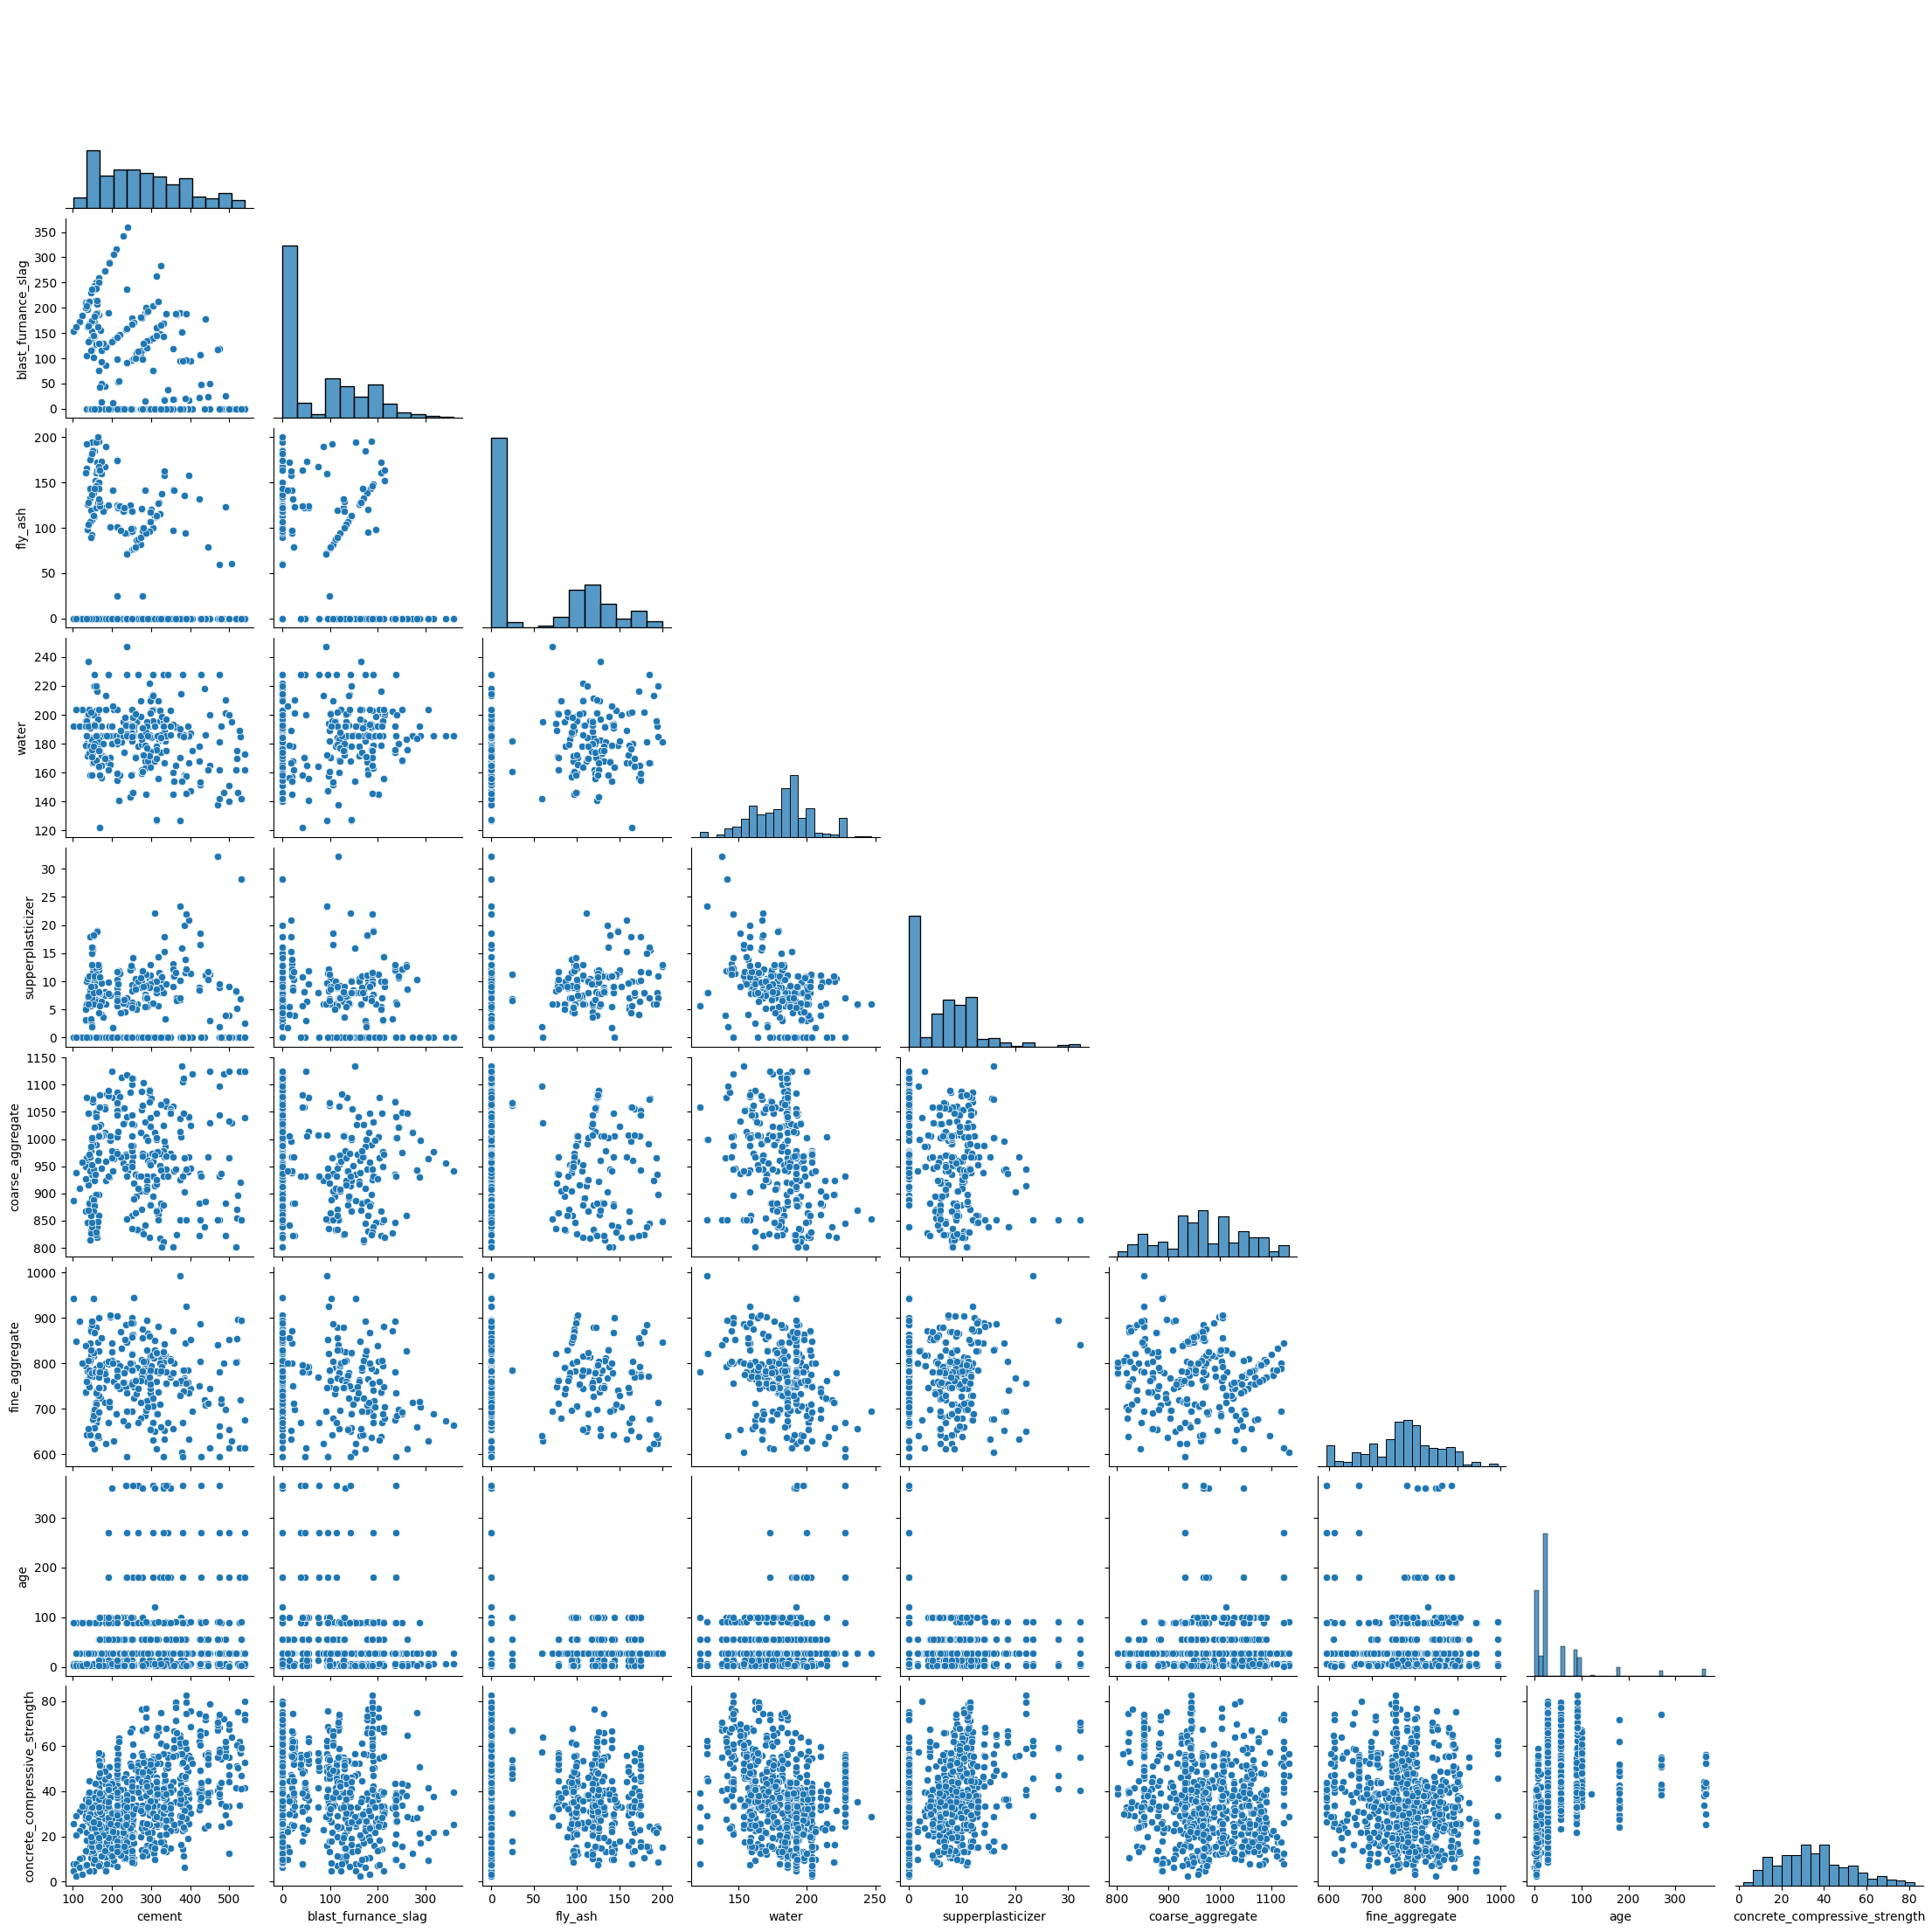

In [7]:
sns.pairplot(df_train, corner=True)
plt.show()

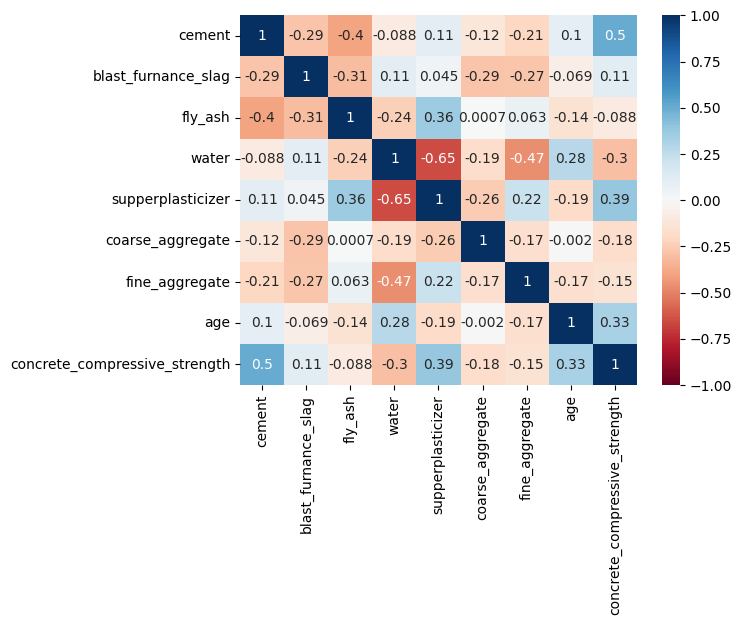

In [8]:
sns.heatmap(df_train.corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True)
plt.show()

In [9]:
#Deep Learning
X_train = df_train.drop(columns=['concrete_compressive_strength'])
y_train = df_train['concrete_compressive_strength']

X_test = df_test.drop(columns=['concrete_compressive_strength'])
y_test = df_test['concrete_compressive_strength']

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
type(X_train_sc), type(y_train)

(numpy.ndarray, pandas.core.series.Series)

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(8,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

/workspaces/clases_4geeks/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-16 18:27:50.669375: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [14]:
model.compile(optimizer='adam', loss='mse', metrics=["mse"]) #Compilacion del modelo
history = model.fit(
    X_train_sc, y_train.values,
    epochs=200, batch_size=100,
    validation_split=0.2
    )

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1562.6924 - mse: 1562.6924 - val_loss: 1357.1030 - val_mse: 1357.1030
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1541.1337 - mse: 1541.1337 - val_loss: 1333.0555 - val_mse: 1333.0555
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1511.5807 - mse: 1511.5807 - val_loss: 1299.4989 - val_mse: 1299.4989
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1470.2747 - mse: 1470.2747 - val_loss: 1255.9280 - val_mse: 1255.9280
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1418.0808 - mse: 1418.0808 - val_loss: 1200.5686 - val_mse: 1200.5686
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1350.7944 - mse: 1350.7944 - val_loss: 1130.2870 - val_mse: 1130.2870
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1265.7206 - mse: 1265.7206 - val_loss: 1041.2570 - val_mse: 1041.2570
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1159.2708 - mse: 1159.2708 - val_loss: 931.7358 - val

In [15]:
loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['mse']
val_mse = history.history['val_mse']

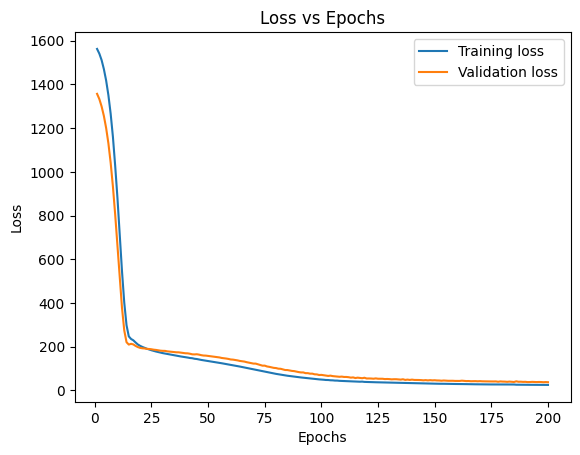

In [16]:
epochs = range(1, len(loss)+1)
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

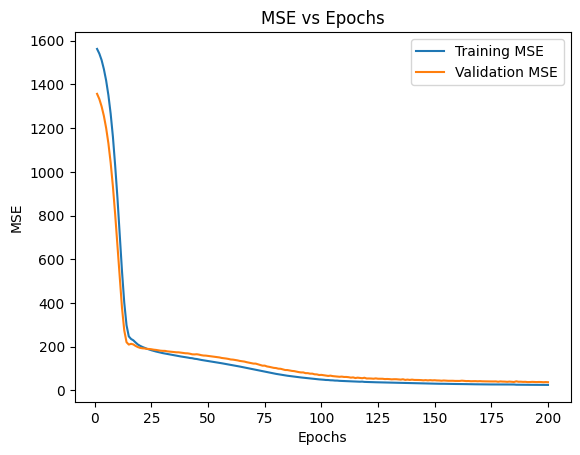

In [17]:
plt.plot(epochs, mse, label='Training MSE')
plt.plot(epochs, val_mse, label='Validation MSE')
plt.title('MSE vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [18]:
loss, mse = model.evaluate(X_test_sc, y_test.values)
print(f'test MSE: {mse}, RMSE: {np.sqrt(mse):.1f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36.4369 - mse: 36.4369 
test MSE: 36.43687438964844, RMSE: 6.0
